## Small Data Domain Generalization for Cross-Platform Sentiment Classification
### Ivan Wang, Evan Zhang, Unlam Leong, Jessie Gu, Raymond Chen

In [ ]:
import os
import json
import pandas as pd
import kagglehub
from datasets import load_dataset
import random
import torch

In [ ]:
# for text normalization + more (emoji not build into python)
# only needed for new runtime
!pip install emoji
#!pip install transformers==4.28.0 nlpaug==1.1.11 tokenizers==0.13.3

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# COUNT AND SEED
# max is 24000 since reddit only has 24107
sample_size = 1000
random_seed = 42
random.seed(random_seed)

## Loading Datasets (Twitter (X), Yelp, Reddit, Amazon, Financial Phrasebank)


In [ ]:
df = pd.read_csv(
    "/content/drive/MyDrive/financial_phrasebank_binary.csv"
)

In [ ]:
#PHRASEBANK DATASET
phrasebank_df = df.drop(columns=["label_name"])
phrasebank_df["domain"] = "phrasebank"
print(phrasebank_df.head())

                                                text  label      domain
0  With the new production plant the company woul...      1  phrasebank
1  For the last quarter of 2010 , Componenta 's n...      1  phrasebank
2  In the third quarter of 2010 , net sales incre...      1  phrasebank
3  Operating profit rose to EUR 13.1 mn from EUR ...      1  phrasebank
4  Operating profit totalled EUR 21.1 mn , up fro...      1  phrasebank


In [ ]:
# YELP DATASET
yelp_path = kagglehub.dataset_download("yelp-dataset/yelp-dataset")
review_file = os.path.join(yelp_path, "yelp_academic_dataset_review.json")
random.seed(random_seed)

# make sure sample_size is even
per_label_size = sample_size // 2

negative_data = []
positive_data = []

negative_seen = 0
positive_seen = 0

# randomly sample evenly from the full Yelp file
with open(review_file, "r", encoding="utf-8") as data_file:
    for line in data_file:
        item = json.loads(line)

        # remove 3 star reviews
        if item["stars"] == 3:
            continue

        # 1-2 stars = negative
        if item["stars"] <= 2:
            negative_seen += 1

            if len(negative_data) < per_label_size:
                negative_data.append(item)
            else:
                j = random.randint(0, negative_seen - 1)

                if j < per_label_size:
                    negative_data[j] = item

        # 4-5 stars = positive
        else:
            positive_seen += 1

            if len(positive_data) < per_label_size:
                positive_data.append(item)
            else:
                j = random.randint(0, positive_seen - 1)

                if j < per_label_size:
                    positive_data[j] = item

# combine balanced data
data = negative_data + positive_data
random.shuffle(data)

# create dataframe
yelp_df = pd.DataFrame(data)

# 1-2 stars = negative, 4-5 stars = positive
yelp_df["label"] = yelp_df["stars"].apply(lambda x: 0 if x <= 2 else 1)

# add domain
yelp_df["domain"] = "yelp"

# keep same format as the other datasets
yelp_df = yelp_df[["text", "label", "domain"]]

# fix types
yelp_df["text"] = yelp_df["text"].astype(str)
yelp_df["label"] = yelp_df["label"].astype(int)
yelp_df["domain"] = yelp_df["domain"].astype(str)

# check balance
print(yelp_df.shape)
print(yelp_df["label"].value_counts())

Using Colab cache for faster access to the 'yelp-dataset' dataset.
(1000, 3)
label
0    500
1    500
Name: count, dtype: int64


In [ ]:
# AMAZON DATASET
amazon = load_dataset("mteb/amazon_polarity", split="train")

# convert to pandas
amazon_df = amazon.to_pandas()

# keep needed columns
amazon_df = amazon_df[["text", "label"]].copy()

# make sure types are right before sampling
amazon_df["text"] = amazon_df["text"].fillna("").astype(str)
amazon_df["label"] = amazon_df["label"].astype(int)

# sample evenly from negative and positive
per_label_size = sample_size // 2

amazon_negative = amazon_df[amazon_df["label"] == 0].sample(
    n=per_label_size,
    random_state=random_seed
)

amazon_positive = amazon_df[amazon_df["label"] == 1].sample(
    n=per_label_size,
    random_state=random_seed
)

amazon_df = pd.concat([amazon_negative, amazon_positive], ignore_index=True)

# shuffle after combining
amazon_df = amazon_df.sample(
    frac=1,
    random_state=random_seed
).reset_index(drop=True)

# add domain column
amazon_df["domain"] = "amazon"

# final same format
amazon_df = amazon_df[["text", "label", "domain"]]

# check balance
print(amazon_df.shape)
print(amazon_df["label"].value_counts())

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


(1000, 3)
label
1    500
0    500
Name: count, dtype: int64


In [ ]:
# TWITTER AND REDDIT DATASETS
tr_path = kagglehub.dataset_download(
    "cosmos98/twitter-and-reddit-sentimental-analysis-dataset"
)

def load_social_sentiment(file_name, text_col, domain):
    file_path = os.path.join(tr_path, file_name)

    df = pd.read_csv(file_path)
    df = df.dropna().copy()

    # remove neutral rows
    df = df[df["category"] != 0].copy()

    # convert labels: -1 negative -> 0, 1 positive -> 1
    df["label"] = df["category"].map({-1: 0, 1: 1})

    # rename text column
    df = df.rename(columns={text_col: "text"})

    # keep only what we need
    df = df[["text", "label"]].copy()

    # make sure types are right before sampling
    df["text"] = df["text"].astype(str)
    df["label"] = df["label"].astype(int)

    # sample evenly from negative and positive
    per_label_size = sample_size // 2

    negative_df = df[df["label"] == 0].sample(
        n=min(per_label_size, len(df[df["label"] == 0])),
        random_state=random_seed
    )

    positive_df = df[df["label"] == 1].sample(
        n=min(per_label_size, len(df[df["label"] == 1])),
        random_state=random_seed
    )

    df = pd.concat([negative_df, positive_df], ignore_index=True)

    # shuffle after combining
    df = df.sample(
        frac=1,
        random_state=random_seed
    ).reset_index(drop=True)

    # add domain
    df["domain"] = domain

    # fix type
    df["domain"] = df["domain"].astype(str)

    # check balance
    print(domain)
    print(df.shape)
    print(df["label"].value_counts())

    return df[["text", "label", "domain"]]


twitter_df = load_social_sentiment(
    "Twitter_Data.csv",
    "clean_text",
    "twitter"
)

reddit_df = load_social_sentiment(
    "Reddit_Data.csv",
    "clean_comment",
    "reddit"
)

Using Colab cache for faster access to the 'twitter-and-reddit-sentimental-analysis-dataset' dataset.
twitter
(1000, 3)
label
1    500
0    500
Name: count, dtype: int64
reddit
(1000, 3)
label
1    500
0    500
Name: count, dtype: int64


In [ ]:
print("YELP")
print(yelp_df.head())
print(yelp_df.columns)
print(yelp_df.dtypes)

print("AMAZON")
print(amazon_df.head())
print(amazon_df.columns)
print(amazon_df.dtypes)

print("TWITTER")
print(twitter_df.head())
print(twitter_df.columns)
print(twitter_df.dtypes)

print("REDDIT")
print(reddit_df.head())
print(reddit_df.columns)
print(reddit_df.dtypes)

print("PHRASEBANK")
print(phrasebank_df.head())
print(phrasebank_df.columns)
print(phrasebank_df.dtypes)

YELP
                                                text  label domain
0  We stayed in the hotel where Feola is located ...      0   yelp
1  Awesome sausage deluxe! Sauce is great with pe...      1   yelp
2  I was killing time in the area and was hungry....      1   yelp
3  It's not just a meal - it's an experience!\n\n...      1   yelp
4  It is always nice to find a good place to eat,...      1   yelp
Index(['text', 'label', 'domain'], dtype='object')
text      object
label      int64
domain    object
dtype: object
AMAZON
                                                text  label  domain
0  Long but very good\n\nIf you have the time, th...      1  amazon
1  High on "HIGH"\n\nIf you are as big a fan of t...      1  amazon
2  good for relaxzation\n\nI wanted something to ...      1  amazon
3  Good Cleaning Cloth\n\nWould you believe that ...      1  amazon
4  Hard boiled boredom\n\nMaybe I have not played...      0  amazon
Index(['text', 'label', 'domain'], dtype='object')
text      o

In [ ]:
# total size
print("Yelp size:", len(yelp_df))
print("Amazon size:", len(amazon_df))
print("Twitter size:", len(twitter_df))
print("Reddit size:", len(reddit_df))
print("Phrasebank size:", len(phrasebank_df))

Yelp size: 1000
Amazon size: 1000
Twitter size: 1000
Reddit size: 1000
Phrasebank size: 1307


In [ ]:
# combining dataframes from all domains
df = pd.concat([yelp_df, amazon_df, twitter_df, reddit_df], ignore_index=True)

df.to_csv("sentiment_data.csv", index=False)

In [ ]:
print(df.shape)
print(df["domain"].value_counts())
print(df["label"].value_counts())

(4000, 3)
domain
yelp       1000
amazon     1000
twitter    1000
reddit     1000
Name: count, dtype: int64
label
0    2000
1    2000
Name: count, dtype: int64


In [ ]:
# BASE PLAN
import random
import re
from functools import lru_cache

import emoji
import nltk
import pandas as pd
import torch
from nltk.corpus import wordnet
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split
from torch.optim import AdamW
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from transformers import DistilBertForSequenceClassification, DistilBertTokenizerFast


seed = 42
random.seed(seed)
torch.manual_seed(seed)

try:
    nltk.download("wordnet", quiet=True)
    nltk.download("omw-1.4", quiet=True)
except Exception as e:
    print("nltk warning:", e, flush=True)

df = pd.read_csv("sentiment_data.csv")

print("data loaded")
print(df.shape)
print(df["domain"].value_counts())
print(df["label"].value_counts())
print(pd.crosstab(df["domain"], df["label"]))

domains = ["yelp", "amazon", "twitter", "reddit"]
fractions = [1.0, 0.5, 0.25, 0.1]

model_dir = "distilbert-base-uncased-local"
tokenizer = DistilBertTokenizerFast.from_pretrained(model_dir)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)
print("cuda:", torch.cuda.is_available())

lr = 2e-5
epochs = 3
batch_size = 16
max_len = 256


class SentimentDataset(Dataset):
    def __init__(self, data, tokenizer, max_len=256):
        self.labels = torch.tensor(data["label"].tolist(), dtype=torch.long)
        self.encodings = tokenizer(
            data["text"].astype(str).tolist(),
            truncation=True,
            padding="max_length",
            max_length=max_len,
            return_tensors="pt"
        )

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            "input_ids": self.encodings["input_ids"][idx],
            "attention_mask": self.encodings["attention_mask"][idx],
            "labels": self.labels[idx]
        }


def clean_text(text):
    text = str(text)
    text = emoji.demojize(text, delimiters=(" ", " "))
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#", "", text)
    text = re.sub(r"(.)\1{2,}", r"\1\1", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


@lru_cache(maxsize=50000)
def get_synonyms(word):
    out = set()

    for syn in wordnet.synsets(word):
        for lemma in syn.lemmas():
            candidate = lemma.name().replace("_", " ")
            if candidate.lower() != word.lower():
                out.add(candidate)

    return list(out)


def synonym_replace(text, p=0.1):
    words = str(text).split()
    new_words = words.copy()

    for i, word in enumerate(words):
        if random.random() < p:
            choices = get_synonyms(word)
            if choices:
                new_words[i] = random.choice(choices)

    return " ".join(new_words)


def balanced_domain_sampler(data):
    counts = data["domain"].value_counts()
    weights = data["domain"].map(lambda d: 1.0 / counts[d])
    weights = torch.tensor(weights.values, dtype=torch.float)

    return WeightedRandomSampler(
        weights,
        num_samples=len(weights),
        replacement=True
    )


results = []

for test_domain in domains:
    for frac in fractions:
        print(f"\nLODO run: test_domain={test_domain}, fraction={frac}", flush=True)

        train_pool = df[df["domain"] != test_domain].copy()
        test_df = df[df["domain"] == test_domain].copy()

        train_pool["text"] = train_pool["text"].apply(clean_text)
        test_df["text"] = test_df["text"].apply(clean_text)

        train_pool = (
            train_pool
            .groupby(["domain", "label"], group_keys=False)
            .sample(frac=frac, random_state=seed)
            .copy()
        )

        train_pool["split_key"] = (
            train_pool["domain"].astype(str) + "_" + train_pool["label"].astype(str)
        )

        print("source balance")
        print(pd.crosstab(train_pool["domain"], train_pool["label"]))

        train_df, val_df = train_test_split(
            train_pool,
            test_size=0.1,
            random_state=seed,
            stratify=train_pool["split_key"]
        )

        aug_df = train_df.copy()
        aug_df["text"] = aug_df["text"].apply(lambda x: synonym_replace(x, p=0.1))

        train_df = pd.concat([train_df, aug_df], ignore_index=True)

        train_df = train_df.drop(columns=["split_key"])
        val_df = val_df.drop(columns=["split_key"])

        print("train:", len(train_df), "val:", len(val_df), "test:", len(test_df), flush=True)

        train_ds = SentimentDataset(train_df, tokenizer, max_len=max_len)
        val_ds = SentimentDataset(val_df, tokenizer, max_len=max_len)
        test_ds = SentimentDataset(test_df, tokenizer, max_len=max_len)

        train_loader = DataLoader(
            train_ds,
            batch_size=batch_size,
            sampler=balanced_domain_sampler(train_df),
            num_workers=0
        )

        val_loader = DataLoader(
            val_ds,
            batch_size=batch_size,
            shuffle=False,
            num_workers=0
        )

        test_loader = DataLoader(
            test_ds,
            batch_size=batch_size,
            shuffle=False,
            num_workers=0
        )

        model = DistilBertForSequenceClassification.from_pretrained(
            model_dir,
            num_labels=2
        ).to(device)

        optimizer = AdamW(model.parameters(), lr=lr)

        final_train_loss = 0
        final_train_acc = 0
        final_val_loss = 0
        final_val_acc = 0

        for epoch in range(epochs):
            model.train()

            total_loss = 0
            correct = 0
            seen = 0

            for batch in train_loader:
                optimizer.zero_grad()

                input_ids = batch["input_ids"].to(device)
                attention_mask = batch["attention_mask"].to(device)
                labels = batch["labels"].to(device)

                out = model(
                    input_ids=input_ids,
                    attention_mask=attention_mask,
                    labels=labels
                )

                loss = out.loss
                preds = out.logits.argmax(dim=1)

                correct += (preds == labels).sum().item()
                seen += labels.size(0)
                total_loss += loss.item()

                loss.backward()
                optimizer.step()

            train_loss = total_loss / len(train_loader)
            train_acc = correct / seen

            model.eval()

            val_loss = 0
            val_correct = 0
            val_seen = 0

            with torch.no_grad():
                for batch in val_loader:
                    input_ids = batch["input_ids"].to(device)
                    attention_mask = batch["attention_mask"].to(device)
                    labels = batch["labels"].to(device)

                    out = model(
                        input_ids=input_ids,
                        attention_mask=attention_mask,
                        labels=labels
                    )

                    val_preds = out.logits.argmax(dim=1)
                    val_correct += (val_preds == labels).sum().item()
                    val_seen += labels.size(0)
                    val_loss += out.loss.item()

            val_loss = val_loss / len(val_loader)
            val_acc = val_correct / val_seen

            final_train_loss = train_loss
            final_train_acc = train_acc
            final_val_loss = val_loss
            final_val_acc = val_acc

            print(
                f"epoch {epoch + 1}: "
                f"train_loss={train_loss:.4f}, "
                f"train_acc={train_acc:.4f}, "
                f"val_loss={val_loss:.4f}, "
                f"val_acc={val_acc:.4f}",
                flush=True
            )

        model.eval()

        preds = []
        trues = []

        with torch.no_grad():
            for batch in test_loader:
                input_ids = batch["input_ids"].to(device)
                attention_mask = batch["attention_mask"].to(device)

                logits = model(
                    input_ids=input_ids,
                    attention_mask=attention_mask
                ).logits

                preds.extend(logits.argmax(dim=1).cpu().numpy())
                trues.extend(batch["labels"].numpy())

        test_acc = accuracy_score(trues, preds)
        test_f1 = f1_score(trues, preds, average="macro")

        print(f"test_acc={test_acc:.4f}, test_f1={test_f1:.4f}", flush=True)

        results.append({
            "test_domain": test_domain,
            "fraction": frac,
            "train_loss": final_train_loss,
            "train_acc": final_train_acc,
            "val_loss": final_val_loss,
            "val_acc": final_val_acc,
            "test_acc": test_acc,
            "test_f1": test_f1
        })

        pd.DataFrame(results).to_csv("results.csv", index=False)
        print("saved results.csv", flush=True)


results_df = pd.DataFrame(results)
results_df.to_csv("results.csv", index=False)

print("\nfinal results")
print(results_df)

print("\nsummary table")
summary = results_df.pivot_table(
    index="test_domain",
    columns="fraction",
    values="test_acc"
).rename(columns={
    1.0: "100%",
    0.5: "50%",
    0.25: "25%",
    0.1: "10%"
})

summary.columns.name = "labeled data"
print(summary.to_string(float_format="{:.4f}".format))

In [ ]:
# MOONSHOT PLAN
import random
import re
from functools import lru_cache

import emoji
import nltk
import pandas as pd
import torch
import torch.nn as nn
from nltk.corpus import wordnet
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split
from torch.optim import AdamW
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from transformers import AutoModel, DistilBertTokenizerFast


seed = 42
random.seed(seed)
torch.manual_seed(seed)

try:
    nltk.download("wordnet", quiet=True)
    nltk.download("omw-1.4", quiet=True)
except Exception as e:
    print("NLTK download warning:", e, flush=True)

df = pd.read_csv("sentiment_data.csv")

print("Loaded data")
print(df.shape)
print(df["domain"].value_counts())
print(df["label"].value_counts())
print(pd.crosstab(df["domain"], df["label"]))

domains = ["yelp", "amazon", "twitter", "reddit"]
fractions = [1.0, 0.5, 0.25, 0.1]

model_dir = "distilbert-base-uncased-local"
tokenizer = DistilBertTokenizerFast.from_pretrained(model_dir)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
print("CUDA available:", torch.cuda.is_available())

epochs = 3
batch_size = 16
max_len = 256

base_lr = 1e-5
head_lr = 1e-4
domain_weight = 1.0
grl_lambda = 0.5


class SentimentDataset(Dataset):
    def __init__(self, data, tokenizer, max_len=256):
        self.labels = torch.tensor(data["label"].tolist(), dtype=torch.long)
        self.encodings = tokenizer(
            data["text"].astype(str).tolist(),
            truncation=True,
            padding="max_length",
            max_length=max_len,
            return_tensors="pt"
        )

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            "input_ids": self.encodings["input_ids"][idx],
            "attention_mask": self.encodings["attention_mask"][idx],
            "labels": self.labels[idx]
        }


def clean_text(text):
    text = str(text)
    text = emoji.demojize(text, delimiters=(" ", " "))
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#", "", text)
    text = re.sub(r"(.)\1{2,}", r"\1\1", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


@lru_cache(maxsize=50000)
def get_synonyms(word):
    out = set()

    for syn in wordnet.synsets(word):
        for lemma in syn.lemmas():
            candidate = lemma.name().replace("_", " ")
            if candidate.lower() != word.lower():
                out.add(candidate)

    return list(out)


def synonym_replace(text, p=0.1):
    words = str(text).split()
    new_words = words.copy()

    for i, word in enumerate(words):
        if random.random() < p:
            choices = get_synonyms(word)
            if choices:
                new_words[i] = random.choice(choices)

    return " ".join(new_words)


def balanced_domain_sampler(data):
    counts = data["domain"].value_counts()
    weights = data["domain"].map(lambda d: 1.0 / counts[d])
    weights = torch.tensor(weights.values, dtype=torch.float)

    return WeightedRandomSampler(
        weights,
        num_samples=len(weights),
        replacement=True
    )


class GradReverse(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x, lambd):
        ctx.lambd = lambd
        return x.view_as(x)

    @staticmethod
    def backward(ctx, grad_output):
        return -ctx.lambd * grad_output, None


def grad_reverse(x, lambd=1.0):
    return GradReverse.apply(x, lambd)


class DANN(nn.Module):
    def __init__(self, model_dir, num_labels=2):
        super().__init__()

        self.encoder = AutoModel.from_pretrained(model_dir)
        hidden_size = self.encoder.config.hidden_size

        self.sentiment_head = nn.Sequential(
            nn.Dropout(0.2),
            nn.Linear(hidden_size, num_labels)
        )

        self.domain_head = nn.Sequential(
            nn.Dropout(0.2),
            nn.Linear(hidden_size, 128),
            nn.ReLU(),
            nn.Linear(128, 2)
        )

    def forward(self, input_ids, attention_mask, lambd=1.0):
        outputs = self.encoder(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        cls_vec = outputs.last_hidden_state[:, 0]

        sentiment_logits = self.sentiment_head(cls_vec)

        reversed_vec = grad_reverse(cls_vec, lambd)
        domain_logits = self.domain_head(reversed_vec)

        return sentiment_logits, domain_logits


sentiment_loss_fn = nn.CrossEntropyLoss()
domain_loss_fn = nn.CrossEntropyLoss()

results = []

for test_domain in domains:
    for frac in fractions:
        print(f"\nDANN LODO: test_domain={test_domain}, fraction={frac}", flush=True)

        source_df = df[df["domain"] != test_domain].copy()
        target_df = df[df["domain"] == test_domain].copy()

        source_df["text"] = source_df["text"].apply(clean_text)
        target_df["text"] = target_df["text"].apply(clean_text)

        source_df = (
            source_df
            .groupby(["domain", "label"], group_keys=False)
            .sample(frac=frac, random_state=seed)
            .copy()
        )

        source_df["split_key"] = (
            source_df["domain"].astype(str) + "_" + source_df["label"].astype(str)
        )

        print("Source balance:")
        print(pd.crosstab(source_df["domain"], source_df["label"]))

        train_df, val_df = train_test_split(
            source_df,
            test_size=0.1,
            random_state=seed,
            stratify=source_df["split_key"]
        )

        aug_df = train_df.copy()
        aug_df["text"] = aug_df["text"].apply(lambda x: synonym_replace(x, p=0.1))

        train_df = pd.concat([train_df, aug_df], ignore_index=True)

        train_df = train_df.drop(columns=["split_key"])
        val_df = val_df.drop(columns=["split_key"])

        print(
            "Train:", len(train_df),
            "Val:", len(val_df),
            "Test:", len(target_df),
            flush=True
        )

        train_ds = SentimentDataset(train_df, tokenizer, max_len=max_len)
        val_ds = SentimentDataset(val_df, tokenizer, max_len=max_len)
        test_ds = SentimentDataset(target_df, tokenizer, max_len=max_len)

        source_loader = DataLoader(
            train_ds,
            batch_size=batch_size,
            sampler=balanced_domain_sampler(train_df),
            num_workers=0
        )

        target_loader = DataLoader(
            test_ds,
            batch_size=batch_size,
            shuffle=True,
            num_workers=0
        )

        val_loader = DataLoader(
            val_ds,
            batch_size=batch_size,
            shuffle=False,
            num_workers=0
        )

        test_loader = DataLoader(
            test_ds,
            batch_size=batch_size,
            shuffle=False,
            num_workers=0
        )

        model = DANN(model_dir=model_dir, num_labels=2).to(device)

        optimizer = AdamW(
            [
                {"params": model.encoder.parameters(), "lr": base_lr},
                {"params": model.sentiment_head.parameters(), "lr": head_lr},
                {"params": model.domain_head.parameters(), "lr": head_lr},
            ]
        )

        final_train_loss = 0
        final_sent_loss = 0
        final_domain_loss = 0
        final_train_acc = 0
        final_val_loss = 0
        final_val_acc = 0

        for epoch in range(epochs):
            model.train()

            total_loss = 0
            total_sent_loss = 0
            total_domain_loss = 0
            correct = 0
            seen = 0

            target_iter = iter(target_loader)

            for source_batch in source_loader:
                try:
                    target_batch = next(target_iter)
                except StopIteration:
                    target_iter = iter(target_loader)
                    target_batch = next(target_iter)

                optimizer.zero_grad()

                source_ids = source_batch["input_ids"].to(device)
                source_mask = source_batch["attention_mask"].to(device)
                source_labels = source_batch["labels"].to(device)

                target_ids = target_batch["input_ids"].to(device)
                target_mask = target_batch["attention_mask"].to(device)

                sentiment_logits, source_domain_logits = model(
                    source_ids,
                    source_mask,
                    lambd=grl_lambda
                )

                _, target_domain_logits = model(
                    target_ids,
                    target_mask,
                    lambd=grl_lambda
                )

                sent_loss = sentiment_loss_fn(sentiment_logits, source_labels)

                source_domain_labels = torch.zeros(
                    source_ids.size(0),
                    dtype=torch.long,
                    device=device
                )

                target_domain_labels = torch.ones(
                    target_ids.size(0),
                    dtype=torch.long,
                    device=device
                )

                domain_logits = torch.cat(
                    [source_domain_logits, target_domain_logits],
                    dim=0
                )

                domain_labels = torch.cat(
                    [source_domain_labels, target_domain_labels],
                    dim=0
                )

                dom_loss = domain_loss_fn(domain_logits, domain_labels)

                loss = sent_loss + domain_weight * dom_loss

                loss.backward()
                optimizer.step()

                total_loss += loss.item()
                total_sent_loss += sent_loss.item()
                total_domain_loss += dom_loss.item()

                preds = sentiment_logits.argmax(dim=1)
                correct += (preds == source_labels).sum().item()
                seen += source_labels.size(0)

            train_loss = total_loss / len(source_loader)
            sent_loss_avg = total_sent_loss / len(source_loader)
            domain_loss_avg = total_domain_loss / len(source_loader)
            train_acc = correct / seen

            model.eval()

            val_loss = 0
            val_correct = 0
            val_seen = 0

            with torch.no_grad():
                for batch in val_loader:
                    input_ids = batch["input_ids"].to(device)
                    attention_mask = batch["attention_mask"].to(device)
                    labels = batch["labels"].to(device)

                    logits, _ = model(
                        input_ids,
                        attention_mask,
                        lambd=0.0
                    )

                    loss = sentiment_loss_fn(logits, labels)

                    val_loss += loss.item()

                    val_preds = logits.argmax(dim=1)
                    val_correct += (val_preds == labels).sum().item()
                    val_seen += labels.size(0)

            val_loss = val_loss / len(val_loader)
            val_acc = val_correct / val_seen

            final_train_loss = train_loss
            final_sent_loss = sent_loss_avg
            final_domain_loss = domain_loss_avg
            final_train_acc = train_acc
            final_val_loss = val_loss
            final_val_acc = val_acc

            print(
                f"Epoch {epoch + 1}: "
                f"train_loss={train_loss:.4f}, "
                f"sent_loss={sent_loss_avg:.4f}, "
                f"domain_loss={domain_loss_avg:.4f}, "
                f"train_acc={train_acc:.4f}, "
                f"val_loss={val_loss:.4f}, "
                f"val_acc={val_acc:.4f}",
                flush=True
            )

        model.eval()

        preds = []
        trues = []

        with torch.no_grad():
            for batch in test_loader:
                input_ids = batch["input_ids"].to(device)
                attention_mask = batch["attention_mask"].to(device)
                labels = batch["labels"]

                logits, _ = model(
                    input_ids,
                    attention_mask,
                    lambd=0.0
                )

                preds.extend(logits.argmax(dim=1).cpu().numpy())
                trues.extend(labels.numpy())

        test_acc = accuracy_score(trues, preds)
        test_f1 = f1_score(trues, preds, average="macro")

        print(f"Test acc={test_acc:.4f}, test_f1={test_f1:.4f}", flush=True)

        results.append({
            "method": "DANN",
            "test_domain": test_domain,
            "fraction": frac,
            "train_loss": final_train_loss,
            "sent_loss": final_sent_loss,
            "domain_loss": final_domain_loss,
            "train_acc": final_train_acc,
            "val_loss": final_val_loss,
            "val_acc": final_val_acc,
            "test_acc": test_acc,
            "test_f1": test_f1
        })

        pd.DataFrame(results).to_csv("dann_results.csv", index=False)
        print("Saved partial results", flush=True)


results_df = pd.DataFrame(results)
results_df.to_csv("dann_results.csv", index=False)

print("\nFinal DANN results")
print(results_df)

print("\nSummary table")
summary = results_df.pivot_table(
    index="test_domain",
    columns="fraction",
    values="test_acc"
).rename(columns={
    1.0: "100%",
    0.5: "50%",
    0.25: "25%",
    0.1: "10%"
})

summary.columns.name = "Labeled Data"
print(summary.to_string(float_format="{:.4f}".format))

In [ ]:
saved_df = pd.read_csv("sentiment_data.csv")

print(saved_df.shape)
print(saved_df["domain"].value_counts())
print(saved_df["label"].value_counts())
print(pd.crosstab(saved_df["domain"], saved_df["label"]))

(4000, 3)
domain
yelp       1000
amazon     1000
twitter    1000
reddit     1000
Name: count, dtype: int64
label
0    2000
1    2000
Name: count, dtype: int64
label      0    1
domain           
amazon   500  500
reddit   500  500
twitter  500  500
yelp     500  500


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


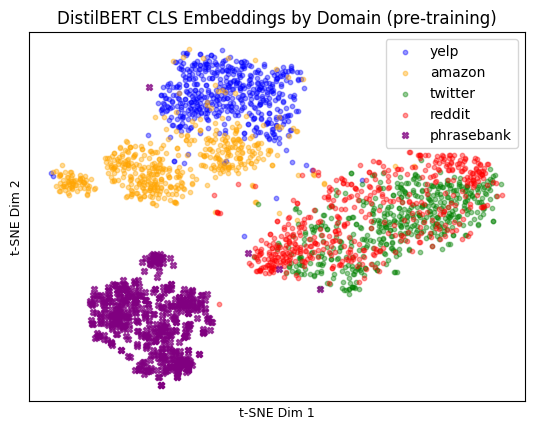

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from torch.utils.data import DataLoader, Dataset
from transformers import DistilBertTokenizerFast, DistilBertModel

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")
model = DistilBertModel.from_pretrained("distilbert-base-uncased").to(device)
model.eval()

# minimal dataset class for extracting the embedding
class TextDataset(Dataset):
    def __init__(self, texts):
        self.texts = texts
    def __len__(self):
        return len(self.texts)
    def __getitem__(self, idx):
        enc = tokenizer(self.texts[idx], truncation=True, padding="max_length", max_length=128, return_tensors="pt")
        return enc["input_ids"].squeeze(0), enc["attention_mask"].squeeze(0)

# include phrasebank in the combined df for sampling
full_df = pd.concat([df, phrasebank_df], ignore_index=True)

# subsample — use fewer for phrasebank if it's small
n_per_domain = 500
sample_parts = []
for domain in ["yelp", "amazon", "twitter", "reddit"]:
    part = full_df[full_df["domain"] == domain].sample(n=n_per_domain, random_state=42)
    sample_parts.append(part)

# sample however many phrasebank has up to 500
phrasebank_sample = full_df[full_df["domain"] == "phrasebank"].sample(
    n=min(n_per_domain, len(full_df[full_df["domain"] == "phrasebank"])),
    random_state=42
)
sample_parts.append(phrasebank_sample)

# subsample to keep it fast
sample_df = pd.concat(sample_parts, ignore_index=True).reset_index(drop=True)

dataset = TextDataset(sample_df["text"].tolist())
loader = DataLoader(dataset, batch_size=32)

embeddings = []
with torch.no_grad():
    for input_ids, attention_mask in loader:
        out = model(input_ids.to(device), attention_mask=attention_mask.to(device))
        cls = out.last_hidden_state[:,0,:].cpu().numpy()
        embeddings.append(cls)
embeddings = np.vstack(embeddings)

# t-SNE reduction
reduced = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(embeddings)

# plot
colors = {
    "yelp": "blue",
    "amazon": "orange",
    "twitter": "green",
    "reddit": "red",
    "phrasebank": "purple"
}
markers = {
    "yelp": "o",
    "amazon": "o",
    "twitter": "o",
    "reddit": "o",
    "phrasebank": "X"  # distinct marker to emphasize it's an outlier domain
}

for domain in ["yelp", "amazon", "twitter", "reddit", "phrasebank"]:
    mask = sample_df["domain"] == domain
    plt.scatter(
        reduced[mask, 0], reduced[mask, 1],
        label=domain,
        color=colors[domain],
        alpha=0.4 if domain != "phrasebank" else 0.7,
        s=10 if domain != "phrasebank" else 20,
        marker=markers[domain]
    )


plt.legend()
plt.title("DistilBERT CLS Embeddings by Domain (pre-training)")
plt.xticks([])
plt.yticks([])
plt.xlabel("t-SNE Dim 1", fontsize=9)
plt.ylabel("t-SNE Dim 2", fontsize=9)
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Baseline + model results
# ----------------------------

raw_distilbert = {
    "yelp": {"acc": 0.5000, "f1": 0.3333},
    "amazon": {"acc": 0.5105, "f1": 0.3675},
    "twitter": {"acc": 0.5015, "f1": 0.3922},
    "reddit": {"acc": 0.5128, "f1": 0.4605},
    "phrasebank": {"acc": 0.322112, "f1": 0.244463},
}

sst2_distilbert = {
    "yelp": {"acc": 0.9373, "f1": 0.9372},
    "amazon": {"acc": 0.8908, "f1": 0.8906},
    "twitter": {"acc": 0.6488, "f1": 0.6308},
    "reddit": {"acc": 0.6395, "f1": 0.6126},
    "phrasebank": {"acc": 0.7047, "f1": 0.7032},
}

# TODO: replace yelp/amazon/twitter/reddit with Ivan screenshot values if needed
# These are the small DANN values you gave earlier.
our_model = {
    "yelp": {"acc": 0.9180, "f1": 0.9180},
    "amazon": {"acc": 0.8790, "f1": 0.8789},
    "twitter": {"acc": 0.7340, "f1": 0.7339},
    "reddit": {"acc": 0.7390, "f1": 0.7381},
    "phrasebank": {"acc": 0.464422, "f1": 0.458647},
}

domains = ["yelp", "amazon", "twitter", "reddit", "phrasebank"]

rows = []
for domain in domains:
    rows.append({
        "model": "Raw DistilBERT",
        "domain": domain,
        "accuracy": raw_distilbert[domain]["acc"],
        "f1": raw_distilbert[domain]["f1"],
    })

    rows.append({
        "model": "SST-2 DistilBERT",
        "domain": domain,
        "accuracy": sst2_distilbert[domain]["acc"],
        "f1": sst2_distilbert[domain]["f1"],
    })

    rows.append({
        "model": "Our DANN Model",
        "domain": domain,
        "accuracy": our_model[domain]["acc"],
        "f1": our_model[domain]["f1"],
    })

results_df = pd.DataFrame(rows)

print(results_df)
results_df.to_csv("./baseline_model_comparison.csv", index=False)

# ----------------------------
# Accuracy comparison
# ----------------------------

x = np.arange(len(domains))
width = 0.25

raw_acc = [raw_distilbert[d]["acc"] for d in domains]
sst2_acc = [sst2_distilbert[d]["acc"] for d in domains]
our_acc = [our_model[d]["acc"] for d in domains]

plt.figure(figsize=(10, 6))
plt.bar(x - width, raw_acc, width, label="Raw DistilBERT")
plt.bar(x, sst2_acc, width, label="SST-2 DistilBERT")
plt.bar(x + width, our_acc, width, label="Our DANN Model")

plt.xticks(x, domains)
plt.ylabel("Accuracy")
plt.title("Accuracy Comparison Across Domains")
plt.ylim(0, 1.0)
plt.legend()
plt.tight_layout()
plt.show()

# ----------------------------
# F1 comparison
# ----------------------------

raw_f1 = [raw_distilbert[d]["f1"] for d in domains]
sst2_f1 = [sst2_distilbert[d]["f1"] for d in domains]
our_f1 = [our_model[d]["f1"] for d in domains]

plt.figure(figsize=(10, 6))
plt.bar(x - width, raw_f1, width, label="Raw DistilBERT")
plt.bar(x, sst2_f1, width, label="SST-2 DistilBERT")
plt.bar(x + width, our_f1, width, label="Our DANN Model")

plt.xticks(x, domains)
plt.ylabel("Macro F1")
plt.title("Macro F1 Comparison Across Domains")
plt.ylim(0, 1.0)
plt.legend()
plt.tight_layout()
plt.show()

FIGURE 1 and FIGURE 2

In [ ]:
# Evaluate trained DANN on all domains

def evaluate_dann_on_df(model, eval_df, tokenizer, device, batch_size=8, max_len=256):
    model.eval()

    eval_df = eval_df.copy()
    eval_df["text"] = eval_df["text"].astype(str).apply(text_normalization)
    eval_df["label"] = eval_df["label"].astype(int)

    eval_ds = SentimentDataset(eval_df, tokenizer, max_len=max_len)

    eval_loader = DataLoader(
        eval_ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0
    )

    preds = []
    trues = []

    with torch.no_grad():
        for batch in eval_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"]

            sentiment_logits, _ = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                lambd=0.0
            )

            preds.extend(sentiment_logits.argmax(dim=1).cpu().numpy())
            trues.extend(labels.numpy())

    acc = accuracy_score(trues, preds)
    f1 = f1_score(trues, preds, average="macro")

    return acc, f1

## Creating Dataloaders (Train, Test Data) + Preprocessing + Training Loop + Evaluation

In [ ]:
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
import nltk
from nltk.corpus import wordnet
import torch
import re
import emoji

nltk.download("wordnet")
nltk.download("omw-1.4")

class SentimentDataset(Dataset):
    def __init__(self, df, tokenizer, max_len=256):
        self.words = df["text"].astype(str).tolist()
        self.labels = df["label"].tolist()
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.words)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.words[idx],
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt"
        )
        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "labels": torch.tensor(self.labels[idx], dtype=torch.long)
        }

# Word Normalization and Emoji Replacement
def text_normalization(text):
    text = str(text)
    text = emoji.demojize(text, delimiters=(" ", " "))
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#", "", text)
    text = re.sub(r"(.)\1{2,}", r"\1\1", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

# Synonym replacement
def synonym(word):
    synonyms = set()
    for syn in wordnet.synsets(word):
        for lemma in syn.lemmas():
            s = lemma.name().replace("_", " ")
            if s.lower() != word.lower():
                synonyms.add(s)
    return list(synonyms)

def synonym_replace(text, aug_p=0.1):
    words = str(text).split()
    new_words = words.copy()
    for i, word in enumerate(words):
        if random.random() < aug_p:
            syns = synonym(word)
            if syns:
                new_words[i] = random.choice(syns)
    return " ".join(new_words)

def make_balanced_sampler(dataset_df):
    domain_counts = dataset_df["domain"].value_counts()
    weights = dataset_df["domain"].map(lambda d: 1.0 / domain_counts[d])
    weights = torch.tensor(weights.values, dtype=torch.float)
    return WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)

domains = ["yelp", "amazon", "twitter", "reddit"]
fractions = [1.0, 0.5, 0.25, 0.1] # using varying percentage of labeled data
tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
lr = 2e-5
epochs = 3

results = []

for test_domain in domains:
    for frac in fractions:
        print(f"\n=== LODO: test_domain={test_domain} | fraction={frac} ===")

        # split into source (3 domains) and test (1 domain)
        source_df = df[df["domain"] != test_domain].copy()
        test_df   = df[df["domain"] == test_domain].copy()

        source_df["text"] = source_df["text"].apply(text_normalization)
        test_df["text"]   = test_df["text"].apply(text_normalization)

        # apply labeled data fraction
        source_df = source_df.groupby("domain").sample(frac=frac, random_state=42).copy()

        source_df["stratify_col"] = (source_df["domain"].astype(str) + "_" + source_df["label"].astype(str))

        # synonym augmentation
        aug_df = source_df.copy()
        aug_df["text"] = aug_df["text"].apply(lambda x: synonym_replace(x, aug_p=0.1))

        combined_df = pd.concat([source_df, aug_df], ignore_index=True)

        train_df, val_df = train_test_split(combined_df, test_size=0.1, random_state=42, stratify=combined_df["stratify_col"])
        train_df = train_df.drop(columns=["stratify_col"])
        val_df   = val_df.drop(columns=["stratify_col"])

        train_ds = SentimentDataset(train_df, tokenizer)
        val_ds   = SentimentDataset(val_df, tokenizer)
        test_ds  = SentimentDataset(test_df, tokenizer)

        train_loader = DataLoader(train_ds, batch_size=16, sampler=make_balanced_sampler(train_df))
        val_loader   = DataLoader(val_ds,   batch_size=16, shuffle=False)
        test_loader  = DataLoader(test_ds,  batch_size=16, shuffle=False)

        model = DistilBertForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=2).to(device)
        optimizer = AdamW(model.parameters(), lr=lr)

        for epoch in range(epochs):
            # Training
            model.train()
            train_loss, train_correct = 0, 0

            for batch in train_loader:
                optimizer.zero_grad()
                input_ids = batch["input_ids"].to(device)
                attention_mask = batch["attention_mask"].to(device)
                labels = batch["labels"].to(device)

                outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
                train_correct += (outputs.logits.argmax(dim=1) == labels).sum().item()
                train_loss += outputs.loss.item()
                outputs.loss.backward()
                optimizer.step()

            train_loss /= len(train_loader)
            train_acc = train_correct / len(train_ds)

            # Evaluation
            model.eval()
            val_loss, val_correct = 0, 0

            with torch.no_grad():
                for batch in val_loader:
                    input_ids = batch["input_ids"].to(device)
                    attention_mask = batch["attention_mask"].to(device)
                    labels = batch["labels"].to(device)

                    outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
                    val_correct += (outputs.logits.argmax(dim=1) == labels).sum().item()
                    val_loss += outputs.loss.item()

            val_loss /= len(val_loader)
            val_acc = val_correct/len(val_ds)

            print(f"  Epoch {epoch+1}: train_loss={train_loss:.4f}  train_acc={train_acc:.4f}  val_loss={val_loss:.4f}  val_acc={val_acc:.4f}")

        # Eval Testing
        model.eval()
        preds, trues = [], []
        with torch.no_grad():
            for batch in test_loader:
                input_ids      = batch["input_ids"].to(device)
                attention_mask = batch["attention_mask"].to(device)
                logits = model(input_ids=input_ids, attention_mask=attention_mask).logits
                preds.extend(logits.argmax(-1).cpu().numpy())
                trues.extend(batch["labels"].numpy())

        acc = accuracy_score(trues, preds)
        f1  = f1_score(trues, preds, average="macro")
        print(f"  → test_acc={acc:.4f} | test_f1={f1:.4f}")

        results.append({"test_domain": test_domain, "fraction": frac, "train_acc": train_acc, "val_acc": val_acc, "test_acc": acc, "test_f1": f1})

results_df = pd.DataFrame(results)
#results_df.to_csv("/content/drive/MyDrive/results.csv", index=False)

print("\n" + "="*75)
print("FINAL RESULTS — Leave-One-Domain-Out (LODO)")
print("="*75)

for domain in domains:
    print(f"\n  Test Domain: {domain.upper()}")
    print(f"{'Fraction':<12} {'Train Acc':<14} {'Val Acc':<14} {'Test Acc':<14} {'Test F1'}")
    print(f"{'-'*10:<12} {'-'*10:<14} {'-'*10:<14} {'-'*10:<14} {'-'*10}")
    for _, row in results_df[results_df["test_domain"] == domain].iterrows():
        print(f"{row['fraction']:<12.0%} {row['train_acc']:<14.4f} {row['val_acc']:<14.4f} {row['test_acc']:<14.4f} {row['test_f1']:.4f}")

print("\n" + "="*75)
print("SUMMARY TABLE")
print("="*75)
pivot = results_df.pivot_table(index="test_domain",columns="fraction",values="test_acc").rename(columns={1.0: "100%", 0.5: "50%", 0.25: "25%", 0.1: "10%"})
pivot.columns.name = "Labeled Data"
print(pivot.to_string(float_format="{:.4f}".format))

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]


=== LODO: test_domain=yelp | fraction=1.0 ===


...

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Epoch 1: train_loss=0.2646  train_acc=0.8870  val_loss=0.1962  val_acc=0.9267
  Epoch 2: train_loss=0.0890  train_acc=0.9698  val_loss=0.1451  val_acc=0.9533
  Epoch 3: train_loss=0.0470  train_acc=0.9849  val_loss=0.1540  val_acc=0.9529
  → test_acc=0.8838 | test_f1=0.8835

=== LODO: test_domain=amazon | fraction=0.5 ===


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


##Summary of Results


In [ ]:
print("\n" + "="*75)
print("FINAL RESULTS — Leave-One-Domain-Out (LODO)")
print("="*75)

for domain in domains:
    print(f"\n  Test Domain: {domain.upper()}")
    print(f"{'Fraction':<12} {'Train Acc':<14} {'Val Acc':<14} {'Test Acc':<14} {'Test F1'}")
    print(f"{'-'*10:<12} {'-'*10:<14} {'-'*10:<14} {'-'*10:<14} {'-'*10}")
    for _, row in results_df[results_df["test_domain"] == domain].iterrows():
        print(f"{row['fraction']:<12.0%} {row['train_acc']:<14.4f} {row['val_acc']:<14.4f} {row['test_acc']:<14.4f} {row['test_f1']:.4f}")

print("\n" + "="*75)
print("SUMMARY TABLE")
print("="*75)
pivot = results_df.pivot_table(index="test_domain",columns="fraction",values="test_acc").rename(columns={1.0: "100%", 0.5: "50%", 0.25: "25%", 0.1: "10%"})
pivot.columns.name = "Labeled Data"
print(pivot.to_string(float_format="{:.4f}".format))

##Plot Train/Val Accuracy and Loss

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("/content/epoch_results.csv")

print(df.columns)

if "epoch" not in df.columns:
    df["epoch"] = df.groupby(
        ["test_domain", "fraction"]
    ).cumcount() + 1

df["fraction_label"] = (
    (df["fraction"] * 100)
    .astype(int)
    .astype(str) + "%"
)

loss_df = df.melt(
    id_vars=[
        "test_domain",
        "fraction",
        "fraction_label",
        "epoch"
    ],
    value_vars=[
        "train_loss",
        "val_loss"
    ],
    var_name="split",
    value_name="loss"
)

g = sns.relplot(
    data=loss_df,
    x="epoch",
    y="loss",
    hue="fraction_label",
    style="split",
    col="test_domain",
    col_wrap=2,
    kind="line",
    marker="o",
    height=4,
    aspect=1.2
)

g.set_titles("Held-out Domain: {col_name}")
g.set_axis_labels("Epoch", "Loss")
g._legend.set_title("Fraction / Split")

plt.suptitle(
    "Training and Validation (In-Domain) Loss by Epoch",
    y=1.03,
    fontsize=16
)

plt.show()

acc_df = df.melt(
    id_vars=[
        "test_domain",
        "fraction",
        "fraction_label",
        "epoch"
    ],
    value_vars=[
        "train_acc",
        "val_acc"
    ],
    var_name="split",
    value_name="accuracy"
)

g = sns.relplot(
    data=acc_df,
    x="epoch",
    y="accuracy",
    hue="fraction_label",
    style="split",
    col="test_domain",
    col_wrap=2,
    kind="line",
    marker="o",
    height=4,
    aspect=1.2
)

g.set_titles("Held-out Domain: {col_name}")
g.set_axis_labels("Epoch", "Accuracy")
g._legend.set_title("Fraction / Split")

plt.suptitle(
    "Training and Validation (In-Domain) Accuracy by Epoch",
    y=1.03,
    fontsize=16
)

plt.show()

final_table = (
    df.sort_values("epoch")
      .groupby(
          ["test_domain", "fraction_label"],
          as_index=False
      )
      .tail(1)
      [[
          "test_domain",
          "fraction_label",
          "train_loss",
          "val_loss",
          "train_acc",
          "val_acc"
      ]]
      .sort_values(
          ["test_domain", "fraction_label"]
      )
)

print("\nFINAL EPOCH RESULTS")
print(final_table.round(4))

##Our Model Evaluation on Test Domain

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, f1_score
import torch
import pandas as pd

model_name = "/content/drive/MyDrive/distilbert-base-uncased-local"

tokenizer = AutoTokenizer.from_pretrained(
    model_name,
    local_files_only=True
)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

domains = ["yelp", "amazon", "twitter", "reddit"]

class SentimentDataset(Dataset):

    def __init__(self, df, tokenizer, max_len=256):

        self.words = df["text"].astype(str).tolist()
        self.labels = df["label"].tolist()
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.words)

    def __getitem__(self, idx):

        encoding = self.tokenizer(
            self.words[idx],
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt"
        )

        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "labels": torch.tensor(
                self.labels[idx],
                dtype=torch.long
            )
        }

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    local_files_only=True
).to(device)

model.eval()

results = []

for test_domain in domains:

    print(f"\n=== Evaluating on {test_domain} ===")

    test_df = df[df["domain"] == test_domain].copy()

    test_ds = SentimentDataset(test_df, tokenizer)

    test_loader = DataLoader(
        test_ds,
        batch_size=64,
        shuffle=False
    )

    preds = []
    trues = []

    with torch.no_grad():

        for batch in test_loader:

            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)

            logits = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            ).logits

            preds.extend(
                logits.argmax(dim=-1).cpu().numpy()
            )

            trues.extend(
                batch["labels"].cpu().numpy()
            )

    acc = accuracy_score(trues, preds)

    f1 = f1_score(
        trues,
        preds,
        average="macro"
    )

    print(f"acc={acc:.4f} | f1={f1:.4f}")

    results.append({
        "test_domain": test_domain,
        "test_acc": acc,
        "test_f1": f1
    })

results_df = pd.DataFrame(results)

print("\n" + "=" * 75)
print("FINAL RESULTS")
print("=" * 75)

for _, row in results_df.iterrows():

    print(
        f"{row['test_domain']:<12} "
        f"acc={row['test_acc']:.4f} | "
        f"f1={row['test_f1']:.4f}"
    )

Loading weights:   0%|          | 0/104 [00:04<?, ?it/s]


=== Evaluating on yelp ===
acc=0.5200 | f1=0.4160

=== Evaluating on amazon ===
acc=0.5070 | f1=0.3649

=== Evaluating on twitter ===
acc=0.5020 | f1=0.3395

=== Evaluating on reddit ===
acc=0.5040 | f1=0.3587

FINAL RESULTS
yelp         acc=0.5200 | f1=0.4160
amazon       acc=0.5070 | f1=0.3649
twitter      acc=0.5020 | f1=0.3395
reddit       acc=0.5040 | f1=0.3587


##Baseline Evaluation

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, f1_score
import torch
import pandas as pd

model_name = "distilbert-base-uncased-finetuned-sst-2-english"

test_domain = 'phrasebank'
tokenizer = AutoTokenizer.from_pretrained(model_name)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class SentimentDataset(Dataset):
    def __init__(self, df, tokenizer, max_len=256):
        self.words = df["text"].astype(str).tolist()
        self.labels = df["label"].tolist()
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.words)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.words[idx],
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt"
        )
        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "labels": torch.tensor(self.labels[idx], dtype=torch.long)
        }

results = []
test_df = phrasebank_df

print(phrasebank_df.head(5))
test_ds = SentimentDataset(test_df, tokenizer)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False)

model = AutoModelForSequenceClassification.from_pretrained(model_name).to(device)
model.eval()

preds, trues = [], []

with torch.no_grad():
  for batch in test_loader:
          input_ids = batch["input_ids"].to(device)
          attention_mask = batch["attention_mask"].to(device)

          logits = model(
                input_ids=input_ids,
                attention_mask=attention_mask
          ).logits

          preds.extend(logits.argmax(dim=-1).cpu().numpy())
          trues.extend(batch["labels"].numpy())

  acc = accuracy_score(trues, preds)
  f1 = f1_score(trues, preds, average="macro")

  print(f"  → test_acc={acc:.4f} | test_f1={f1:.4f}")

  results.append({
        "test_domain": test_domain,
        "test_acc": acc,
        "test_f1": f1
    })

results_df = pd.DataFrame(results)

print("\n" + "=" * 75)
print("FINAL RESULTS — SST-2 FINE-TUNED DISTILBERT BASELINE")
print("=" * 75)

for _, row in results_df.iterrows():
    print(
        f"{row['test_domain']:<12} "
        f"acc={row['test_acc']:.4f} | "
        f"f1={row['test_f1']:.4f}"
    )

In [ ]:
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, f1_score
import torch
import pandas as pd

model_name = "distilbert-base-uncased"

tokenizer = DistilBertTokenizerFast.from_pretrained(model_name)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class SentimentDataset(Dataset):
    def __init__(self, df, tokenizer, max_len=256):
        self.words = df["text"].astype(str).tolist()
        self.labels = df["label"].astype(int).tolist()
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.words)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.words[idx],
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt"
        )
        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "labels": torch.tensor(self.labels[idx], dtype=torch.long)
        }

results = []

test_df = phrasebank_df.copy()
test_df = test_df.dropna(subset=["text", "label"])
test_df["label"] = test_df["label"].astype(int)

print(test_df.head())

test_ds = SentimentDataset(test_df, tokenizer)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False)

model = DistilBertForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2
).to(device)

model.eval()

preds, trues = [], []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)

        logits = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        ).logits

        preds.extend(logits.argmax(dim=-1).cpu().numpy())
        trues.extend(batch["labels"].numpy())

acc = accuracy_score(trues, preds)
f1 = f1_score(trues, preds, average="macro")

print(f"  → test_acc={acc:.4f} | test_f1={f1:.4f}")

results.append({
    "test_domain": "phrasebank",
    "test_acc": acc,
    "test_f1": f1
})

results_df = pd.DataFrame(results)
print(results_df)

## Model

## Training Loop

##DANN Implementation

##Our Model Evaluation on Test Set

In [ ]:
model_path = "/content/drive/MyDrive/distilbert-base-uncased-local"

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
model_path = "/content/drive/MyDrive/distilbert-base-uncased-local"

tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForSequenceClassification.from_pretrained(model_path)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
model.eval()

In [ ]:
results = []

test_df = phrasebank_df.copy()
test_df = test_df.dropna(subset=["text", "label"])
test_df["label"] = test_df["label"].astype(int)

print(test_df.head())

test_ds = SentimentDataset(test_df, tokenizer)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False)

model.eval()

preds, trues = [], []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)

        logits = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        ).logits

        preds.extend(logits.argmax(dim=-1).cpu().numpy())
        trues.extend(batch["labels"].numpy())

acc = accuracy_score(trues, preds)
f1 = f1_score(trues, preds, average="macro")

print(f"  → test_acc={acc:.4f} | test_f1={f1:.4f}")

results.append({
    "test_domain": "phrasebank",
    "test_acc": acc,
    "test_f1": f1
})

results_df = pd.DataFrame(results)
print(results_df)

##DANN Plots

Index(['method', 'run', 'test_domain', 'fraction', 'epoch', 'train_loss',
       'sent_loss', 'domain_loss', 'train_acc', 'val_loss', 'val_acc',
       'test_acc', 'test_f1'],
      dtype='object')


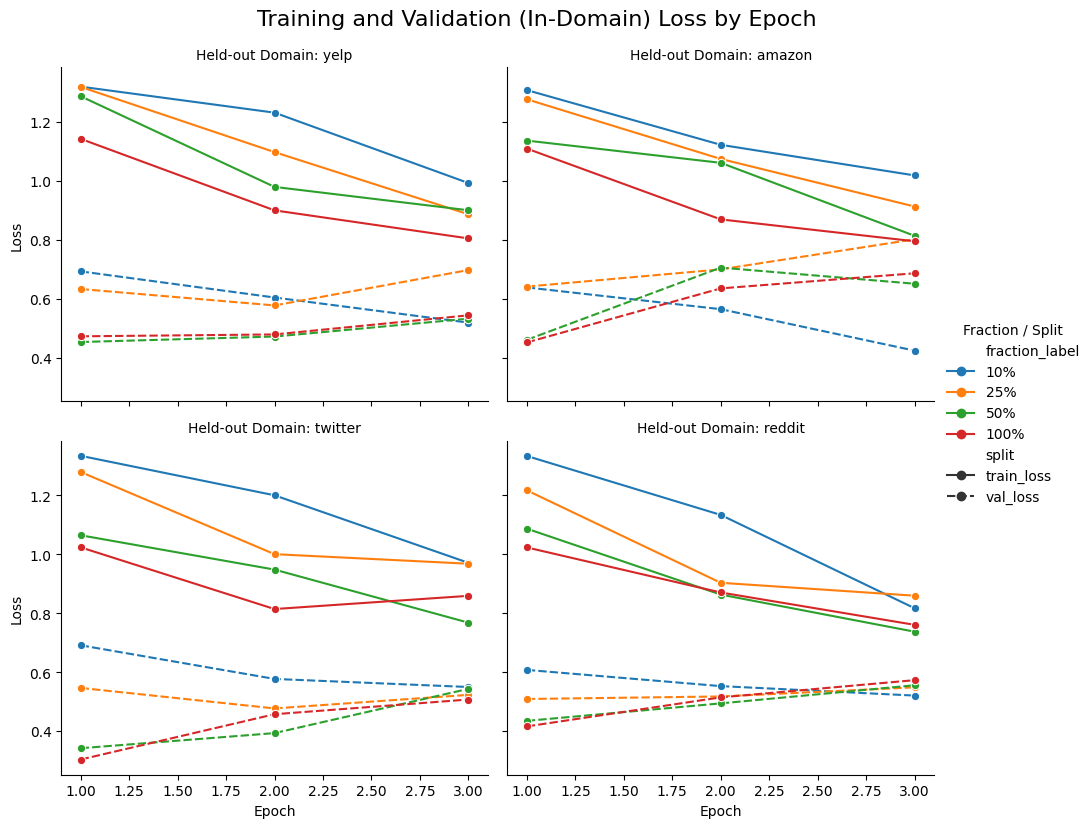

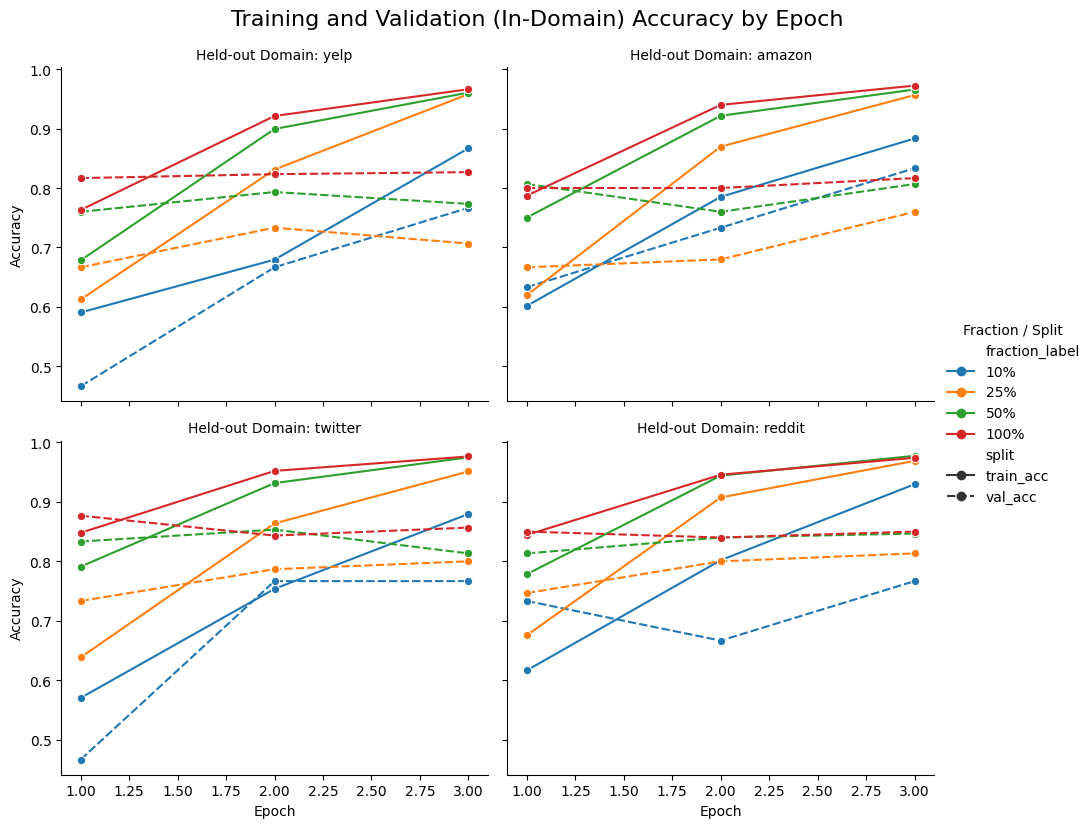


FINAL EPOCH RESULTS
   test_domain fraction_label  train_loss  val_loss  train_acc  val_acc
14      amazon            10%      1.0185    0.4237     0.8833   0.8333
23      amazon           100%      0.7950    0.6863     0.9722   0.8167
17      amazon            25%      0.9129    0.8017     0.9563   0.7600
20      amazon            50%      0.8135    0.6509     0.9656   0.8067
38      reddit            10%      0.8164    0.5200     0.9296   0.7667
47      reddit           100%      0.7601    0.5723     0.9741   0.8500
41      reddit            25%      0.8590    0.5480     0.9689   0.8133
44      reddit            50%      0.7368    0.5550     0.9774   0.8467
26     twitter            10%      0.9706    0.5491     0.8796   0.7667
35     twitter           100%      0.8585    0.5066     0.9763   0.8567
29     twitter            25%      0.9675    0.5224     0.9511   0.8000
32     twitter            50%      0.7675    0.5428     0.9748   0.8133
2         yelp            10%      0.9927  

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("small_dann_epoch_results-1.csv")

print(df.columns)

if "epoch" not in df.columns:
    df["epoch"] = df.groupby(
        ["test_domain", "fraction"]
    ).cumcount() + 1

df["fraction_label"] = (
    (df["fraction"] * 100)
    .astype(int)
    .astype(str) + "%"
)

loss_df = df.melt(
    id_vars=[
        "test_domain",
        "fraction",
        "fraction_label",
        "epoch"
    ],
    value_vars=[
        "train_loss",
        "val_loss"
    ],
    var_name="split",
    value_name="loss"
)

g = sns.relplot(
    data=loss_df,
    x="epoch",
    y="loss",
    hue="fraction_label",
    style="split",
    col="test_domain",
    col_wrap=2,
    kind="line",
    marker="o",
    height=4,
    aspect=1.2
)

g.set_titles("Held-out Domain: {col_name}")
g.set_axis_labels("Epoch", "Loss")
g._legend.set_title("Fraction / Split")

plt.suptitle(
    "Training and Validation (In-Domain) Loss by Epoch",
    y=1.03,
    fontsize=16
)

plt.show()

acc_df = df.melt(
    id_vars=[
        "test_domain",
        "fraction",
        "fraction_label",
        "epoch"
    ],
    value_vars=[
        "train_acc",
        "val_acc"
    ],
    var_name="split",
    value_name="accuracy"
)

g = sns.relplot(
    data=acc_df,
    x="epoch",
    y="accuracy",
    hue="fraction_label",
    style="split",
    col="test_domain",
    col_wrap=2,
    kind="line",
    marker="o",
    height=4,
    aspect=1.2
)

g.set_titles("Held-out Domain: {col_name}")
g.set_axis_labels("Epoch", "Accuracy")
g._legend.set_title("Fraction / Split")

plt.suptitle(
    "Training and Validation (In-Domain) Accuracy by Epoch",
    y=1.03,
    fontsize=16
)

plt.show()

final_table = (
    df.sort_values("epoch")
      .groupby(
          ["test_domain", "fraction_label"],
          as_index=False
      )
      .tail(1)
      [[
          "test_domain",
          "fraction_label",
          "train_loss",
          "val_loss",
          "train_acc",
          "val_acc"
      ]]
      .sort_values(
          ["test_domain", "fraction_label"]
      )
)

print("\nFINAL EPOCH RESULTS")
print(final_table.round(4))

## Visualization